<a href="https://colab.research.google.com/github/Halgratir/Gacha-Games/blob/main/Gacha_Games.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import CSV

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Setting the visual style for charts
sns.set_theme(style="whitegrid")

**Load Data**

In [158]:
gacha_df = pd.read_csv('/content/Gacha_Games - Sheet 1.csv')
gacha_df.head(10)

,Game_Title,Art_Style,Gacha_Type,Status,Monthly_F2P_Pull_Income,Currency_Cost_Per_Pull_USD,Banner_Duration,Platform,Region,Probability_Highest_Rate,Hard_Pity,Hard_Pity_Count,Soft_Pity,Monthly_Downloads,Lifetime_Downloads,Highest_Revenue_Monthly,Lowest_Revenue_Monthly,Age_Rating,Developers
0,100 Sleeping Princes and the Kingdom of Dreams,Anime 2D,Characters,Active,50,2.50,14,"Android, iOS","Japan, China, Taiwan, Korea",0.0350,Yes,No,No,"15,000","12,000,000","5,000,000","120,000",12,GCREST Inc.
1,2.5 Dimensional Seduction: Angels on Stage,Anime 3D,Characters,Service Ending,50,2.20,14,"Android, iOS, PC",Japan,0.0300,Yes,200,Yes,"250,000","2,000,000","2,000,000","20,000",17,Team CARAVAN
2,Compass,Anime 3D,Characters,Active,50,2.00,14,"Android, iOS",Japan,0.0100,No,No,No,"20,000","15,000,000","3,000,000","800,000",12,NHN PlayArt Co. Ltd.
3,ABYSSDIA,Anime 2D,"Characters, Artifacts",Active,50,2.25,14,"Android, iOS, PC","Japan, Global",0.0300,Yes,No,No,"30,000","5,000,000","40,000","5,000",12,"Ring Games Co,. Ltd"
4,Action Tamarin,Anime 3D,"Characters, Supporters",Active,50,2.25,14,"Android, iOS, PC, Nintendo Switch","Japan, Global",0.0300,Yes,100,No,"25,000","3,000,000","800,000","120,000",17,Gremory Games
5,Aether Gazer,Anime 3D,"Characters, Modifiers",Active,70,2.00,21,"Android, iOS, PC","China, Global",0.0160,Yes,140,Yes,"80,000","5,000,000","2,100,000","274,000",12,Yongshi
6,AFK Arena,Stylized 2D,Heroes,Active,80,2.50,14,"Android, iOS",Global,0.0461,Yes,No,No,"40,000","50,000,000","105,400,000","2,000,000",12,Lilith Games
7,AFK Journey,Stylized 3D,Heroes,Active,65,2.25,21,"Android, iOS, PC",Global,0.0205,Yes,40,Yes,"1,200,000","18,000,000","71,800,000","2,590,000",12,Lilith Games
8,Age of Ishtaria,Anime 2D,Cards,Active,50,2.25,14,"Android, iOS, PC","Japan, North America",0.0200,No,No,No,"5,000","5,000,000","1,000,000","30,000",12,Silicon Studio
9,Alchemy Stars,Anime 2D,Characters,Closed,55,2.30,14,"Android, iOS, PC","Global, China",0.0200,Yes,270,No,"50,000","15,000,000","8,000,000","150,000",12,Tourdog Studio


In [160]:
print(f"Dataset Dimensions: {gacha_df.shape}")
gacha_df.info()
print(f"Missing Values: {gacha_df.isnull().sum()}")

Dataset Dimensions: (416, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Game_Title                  416 non-null    object 
 1   Art_Style                   416 non-null    object 
 2   Gacha_Type                  414 non-null    object 
 3   Status                      416 non-null    object 
 4   Monthly_F2P_Pull_Income     416 non-null    int64  
 5   Currency_Cost_Per_Pull_USD  416 non-null    float64
 6   Banner_Duration             416 non-null    int64  
 7   Platform                    416 non-null    object 
 8   Region                      368 non-null    object 
 9   Probability_Highest_Rate    416 non-null    float64
 10  Hard_Pity                   416 non-null    object 
 11  Hard_Pity_Count             416 non-null    object 
 12  Soft_Pity                   416 non-null    object 
 13  Month

Success! It reads

If the preview does not load on my github repo. Here is the link to view it: https://nbviewer.org/

**Clean the data**

In [161]:
#Cleaning and transforming
cols_to_fix = ['Monthly_Downloads', 'Lifetime_Downloads', 'Highest_Revenue_Monthly', 'Lowest_Revenue_Monthly']
for col in cols_to_fix:
  gacha_df[col] = pd.to_numeric(gacha_df[col], errors='coerce')

#checking tables
print(gacha_df.dtypes)

Game_Title                     object
Art_Style                      object
Gacha_Type                     object
Status                         object
Monthly_F2P_Pull_Income         int64
Currency_Cost_Per_Pull_USD    float64
Banner_Duration                 int64
Platform                       object
Region                         object
Probability_Highest_Rate      float64
Hard_Pity                      object
Hard_Pity_Count                object
Soft_Pity                      object
Monthly_Downloads             float64
Lifetime_Downloads            float64
Highest_Revenue_Monthly       float64
Lowest_Revenue_Monthly        float64
Age_Rating                      int64
Developers                     object
dtype: object


**CLEAN CLEAN CLEAN**

In [162]:
#Clean hard Pity Count by converting 'No' into 0
gacha_df['pity_count_numeric'] = pd.to_numeric(gacha_df['Hard_Pity_Count'].replace('No', 0))

#Calculate pity cost pulls (Pulls needed * Cost per pull)
gacha_df['pity_cost_usd'] = gacha_df['pity_count_numeric'] * gacha_df['Currency_Cost_Per_Pull_USD']

#Handle missing values/revenue
gacha_df['Highest_Revenue_Monthly'] = gacha_df['Highest_Revenue_Monthly'].fillna(0)
gacha_df['Monthly_Downloads'] = gacha_df['Monthly_Downloads'].fillna(0)

print("Data Cleaning Complete!")
gacha_df[['Game_Title', 'pity_count_numeric', 'pity_cost_usd']].head()

Data Cleaning Complete!


,Game_Title,pity_count_numeric,pity_cost_usd
0,100 Sleeping Princes and the Kingdom of Dreams,0,0.0
1,2.5 Dimensional Seduction: Angels on Stage,200,440.0
2,Compass,0,0.0
3,ABYSSDIA,0,0.0
4,Action Tamarin,100,225.0


**Python FUNCTION and CLASS**

In [156]:
#python function
def categorize_pity(count):
  #categorizes the 'friendliness' of the pity system'
  if count ==0:
    return "No Guarantee"
  elif count <= 90:
    return "Player Friendly"
  elif count <= 100:
    return "Standard"
  else:
    return "Expensive"

df['pity_tier'] = df['pity_count_numeric'].apply(categorize_pity)
gacha_df['pity_category'] = gacha_df['hard_pity_count_num'].apply(categorize_pity)
print(gacha_df[['Game_Title', 'pity_category']].head(10)

SyntaxError: incomplete input (1811731717.py, line 15)

In [153]:
#Python class
class GachaAnalysis:
  def __init__(self, data):
        self.data = data
  def get_market_leader(self):
        top_game = self.data.loc[self.data['Highest_Revenue_Monthly'].idxmax()]
        return f"Market Leader: {top_game['Game_Title']} with ${top_game['Highest_Revenue_Monthly']:,} Monthly Revenue."

#using the class
analysis = GachaAnalysis(df)
print(analysis.get_market_leader())

Market Leader: Fate Grand Order with $200,000,000 Monthly Revenue.


**Visualize Art Style versus Revenue**

/tmp/ipykernel_29060/3413670344.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=art_revenue.index, y=art_revenue.values, palette='viridis')


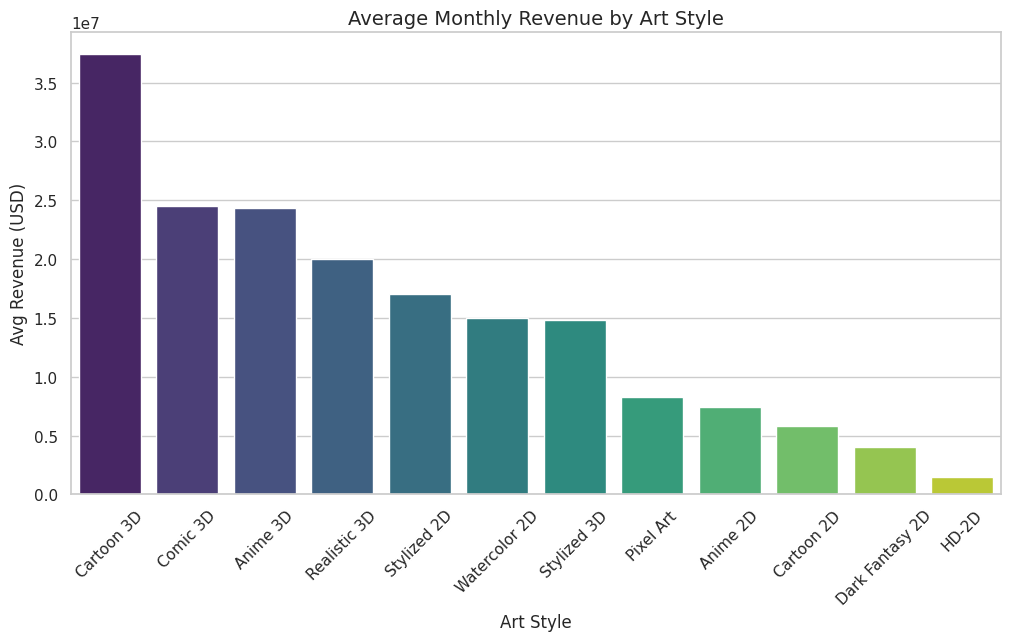

In [151]:
#Group by art and revenue
art_revenue = df.groupby('Art_Style')['Highest_Revenue_Monthly'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=art_revenue.index, y=art_revenue.values, palette='viridis')
plt.title('Average Monthly Revenue by Art Style', fontsize=14)
plt.xlabel('Art Style')
plt.ylabel('Avg Revenue (USD)')
plt.xticks(rotation=45)
plt.show()

**Linear Regression**

Does Popularity downloads actually predict success revenue?

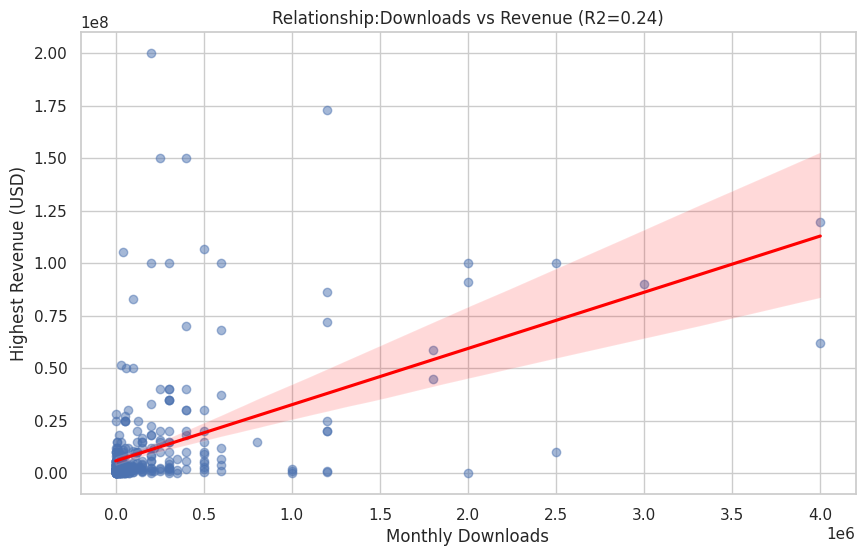

In [152]:
#prepare the DATA
X = df[['Monthly_Downloads']]
Y = df['Highest_Revenue_Monthly']
#create and fit the model
model = LinearRegression().fit(X, y)
r_squared = model.score(X, y)
#Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='Monthly_Downloads', y='Highest_Revenue_Monthly', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title(f'Relationship:Downloads vs Revenue (R2={r_squared:.2f})')
plt.xlabel('Monthly Downloads')
plt.ylabel('Highest Revenue (USD)')
plt.show()